In [1]:
from torch.utils.data import Dataset, DataLoader

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

from VAE import VAE

In [2]:
import torch
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

import glob
import os
from torch.utils.data import Dataset

import os
import torch
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms

class PineappleTripletDataset(Dataset):
    def __init__(self, root_dir, train=True, train_ratio=0.8, resize_shape=(256, 256)):
        """
        Args:
            root_dir (string): Directory with all the images organized in subfolders for each class.
            train (bool, optional): If True, use the training set. If False, use the validation set.
            train_ratio (float, optional): Ratio to split the data into training and validation sets.
            resize_shape (tuple, optional): The target size (height, width) for resizing the images.
        """
        self.root_dir = root_dir
        self.train = train
        self.train_ratio = train_ratio
        self.resize_shape = resize_shape
        self.classes = sorted(os.listdir(root_dir))  # Ensures consistent label ordering

        # Create mapping from label number to class name
        self.label_to_text = {i: class_name for i, class_name in enumerate(self.classes)}

        self.image_paths = []
        self.labels = []

        # Populate image paths and numeric labels
        for label, class_name in enumerate(self.classes):
            class_folder = os.path.join(root_dir, class_name)
            if os.path.isdir(class_folder):
                for img_name in os.listdir(class_folder):
                    img_path = os.path.join(class_folder, img_name)
                    if img_path.endswith(('.png', '.jpg', '.jpeg')):
                        self.image_paths.append(img_path)
                        self.labels.append(label)

        # Split dataset
        total_samples = len(self.image_paths)
        train_size = int(self.train_ratio * total_samples)
        indices = torch.randperm(total_samples).tolist()
        train_indices = indices[:train_size]
        val_indices = indices[train_size:]

        if self.train:
            self.image_paths = [self.image_paths[i] for i in train_indices]
            self.labels = [self.labels[i] for i in train_indices]
        else:
            self.image_paths = [self.image_paths[i] for i in val_indices]
            self.labels = [self.labels[i] for i in val_indices]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = self.load_and_transform(img_path)

        return {
            "image": image,
            "label": label,
            "label_text": self.label_to_text[label]  # Optional: return the string label
        }

    def load_and_transform(self, image_path):
        image = cv2.imread(image_path, cv2.IMREAD_COLOR)
        channels = 3
        image = cv2.resize(image, dsize=(self.resize_shape[1], self.resize_shape[0]))
        image = np.array(image).reshape((image.shape[0], image.shape[1], channels)).astype(np.float32) / 255.0
        image = np.transpose(image, (2, 0, 1))
        return image




def extract_and_visualize_latents(model, test_loader, device='cuda'):
    model.eval()
    model.to(device)

    all_latents = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_tensor = batch['image'].to(device)

            batch_size, _, height, width = input_tensor.shape
            noise = torch.randn((batch_size, 4, height // 8, width // 8), device=device)
            latent, mean, logvar = model.encoder(input_tensor, noise)

            all_latents.append(latent.squeeze(0).cpu().numpy())
            all_labels.extend(batch['label'])

    # Stack latents
    all_latents = np.stack(all_latents)
    print(f"{all_latents.shape[0]} latent vectors extracted")

    # Reshape to 2D and remove NaNs
    reshaped_data = all_latents.reshape(all_latents.shape[0], -1)
    nan_mask = ~np.isnan(reshaped_data).any(axis=1)
    data_cleaned = reshaped_data[nan_mask]
    label_cleaned = np.array(all_labels)[nan_mask]

    print(f"Cleaned data shape: {data_cleaned.shape}")

    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=0)
    clustered_data = tsne.fit_transform(data_cleaned)

    # Convert labels to colors
    label_colors = {0: 'blue', 1: 'green', 2: 'red'}
    label_names = {0: 'background', 1: 'foreground', 2: 'full'}

    # Plot each class separately to enable legend
    plt.figure(figsize=(10, 8))
    for label in np.unique(label_cleaned):
        idxs = label_cleaned == label
        plt.scatter(
            clustered_data[idxs, 0],
            clustered_data[idxs, 1],
            c=label_colors[label],
            label=label_names[label],
            alpha=0.7
        )

    plt.title("t-SNE Clustering of Flattened Latents")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    
def visualize_reconstructions(model, test_set, num_samples=5, device='cuda', img="image"):
    """
    Visualizes original and reconstructed images side by side.
    
    Args:
        model: Trained model with a forward method that returns reconstructions.
        test_set: Dataset providing dicts with 'image' keys.
        num_samples: Number of random samples to display.
        device: 'cuda' or 'cpu'.
    """
    model.eval()
    model.to(device)

    fig = plt.figure(figsize=(4 * num_samples, 8))  # Wide figure
    rows, columns = 2, num_samples  # Original + reconstructed rows

    for i in range(columns):
        index = np.random.randint(len(test_set))

        # Get original image and convert to tensor
        original_image = test_set[index][img]
        input_tensor = torch.tensor(original_image).unsqueeze(0).to(device)

        # Model inference
        with torch.no_grad():
            reconstructed_image, _, _ = model(input_tensor)

        # Convert images for display
        original_image_disp = (original_image.transpose((1, 2, 0)) * 255).astype(np.uint8)
        reconstructed_image = reconstructed_image.squeeze(0).cpu().numpy()
        reconstructed_image_disp = (reconstructed_image.transpose((1, 2, 0)) * 255).astype(np.uint8)

        # Plot original
        ax = fig.add_subplot(rows, columns, i + 1)
        ax.set_title('Original')
        ax.imshow(original_image_disp)
        ax.axis('off')

        # Plot reconstructed
        ax = fig.add_subplot(rows, columns, i + 1 + columns)
        ax.set_title('Reconstructed')
        ax.imshow(reconstructed_image_disp)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [3]:
test_set = PineappleTripletDataset(train=False, train_ratio=0.8, root_dir="/home/rtxmsi1/Documents/VAE_training-master/dataset")
test_loader = DataLoader(test_set, batch_size=1, shuffle=False, num_workers=2)

In [4]:
test_set.label_to_text

{0: 'backgrounds', 1: 'foregrounds', 2: 'full'}

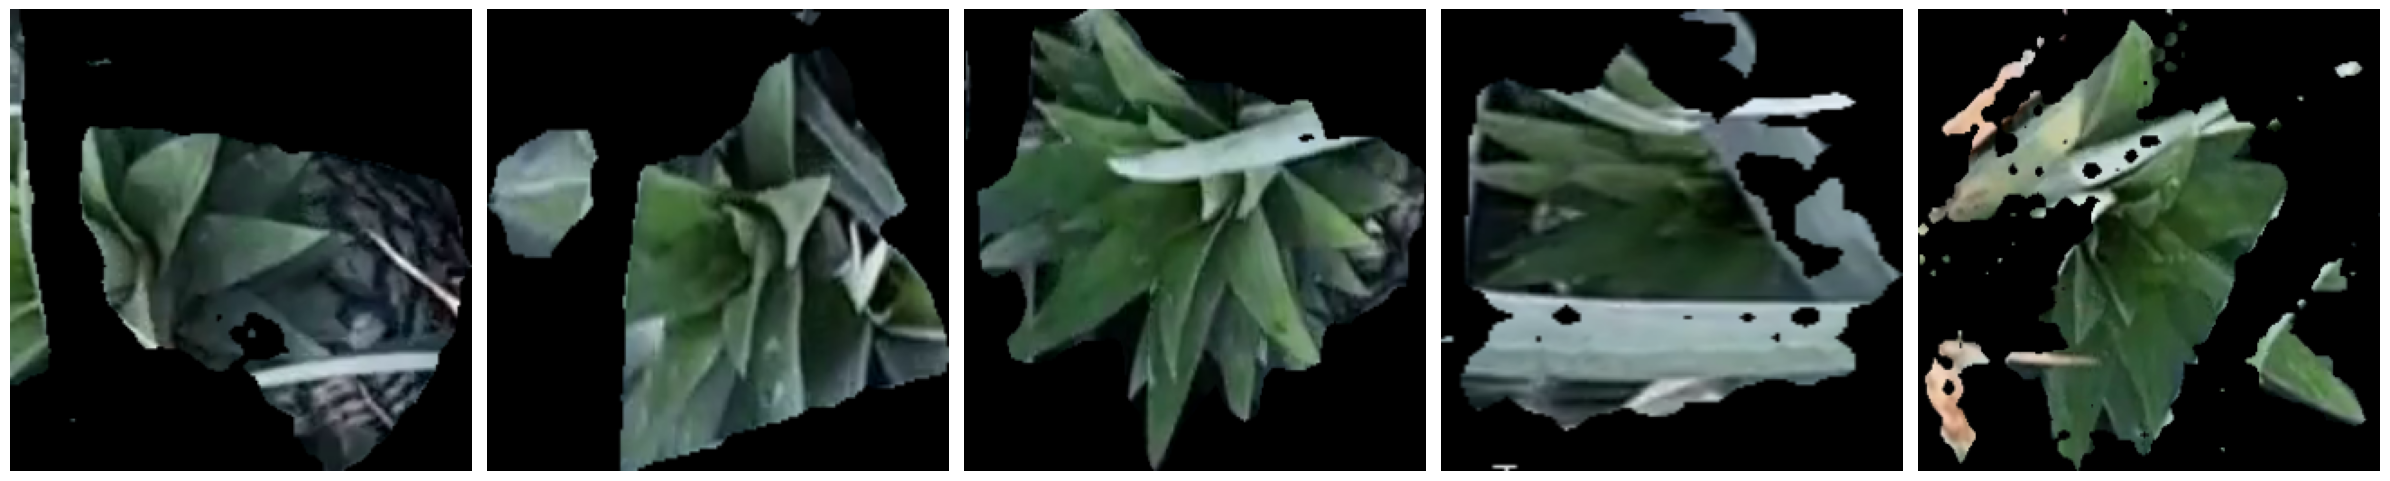

In [5]:
fig = plt.figure(figsize=(24, 6))  # Wider and shorter for horizontal layout
rows = 1
columns = 5

for i in range(columns):
    batch = test_set[np.random.randint(len(test_set))]
    img = batch['image'].transpose((1, 2, 0))  # Convert CHW to HWC
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    fig.add_subplot(rows, columns, i + 1)
    plt.imshow(img)
    plt.axis('off')  # Hide axis for better presentation

plt.tight_layout()
plt.show()

In [6]:
model = VAE()
checkpoint_path = "/home/rtxmsi1/Documents/VAE_training-master/checkpoints/vae/betaKL@0.0/weights_ck_198.pt"  # Replace with your checkpoint file
checkpoint = torch.load(checkpoint_path)
model.load_state_dict(checkpoint)

<All keys matched successfully>

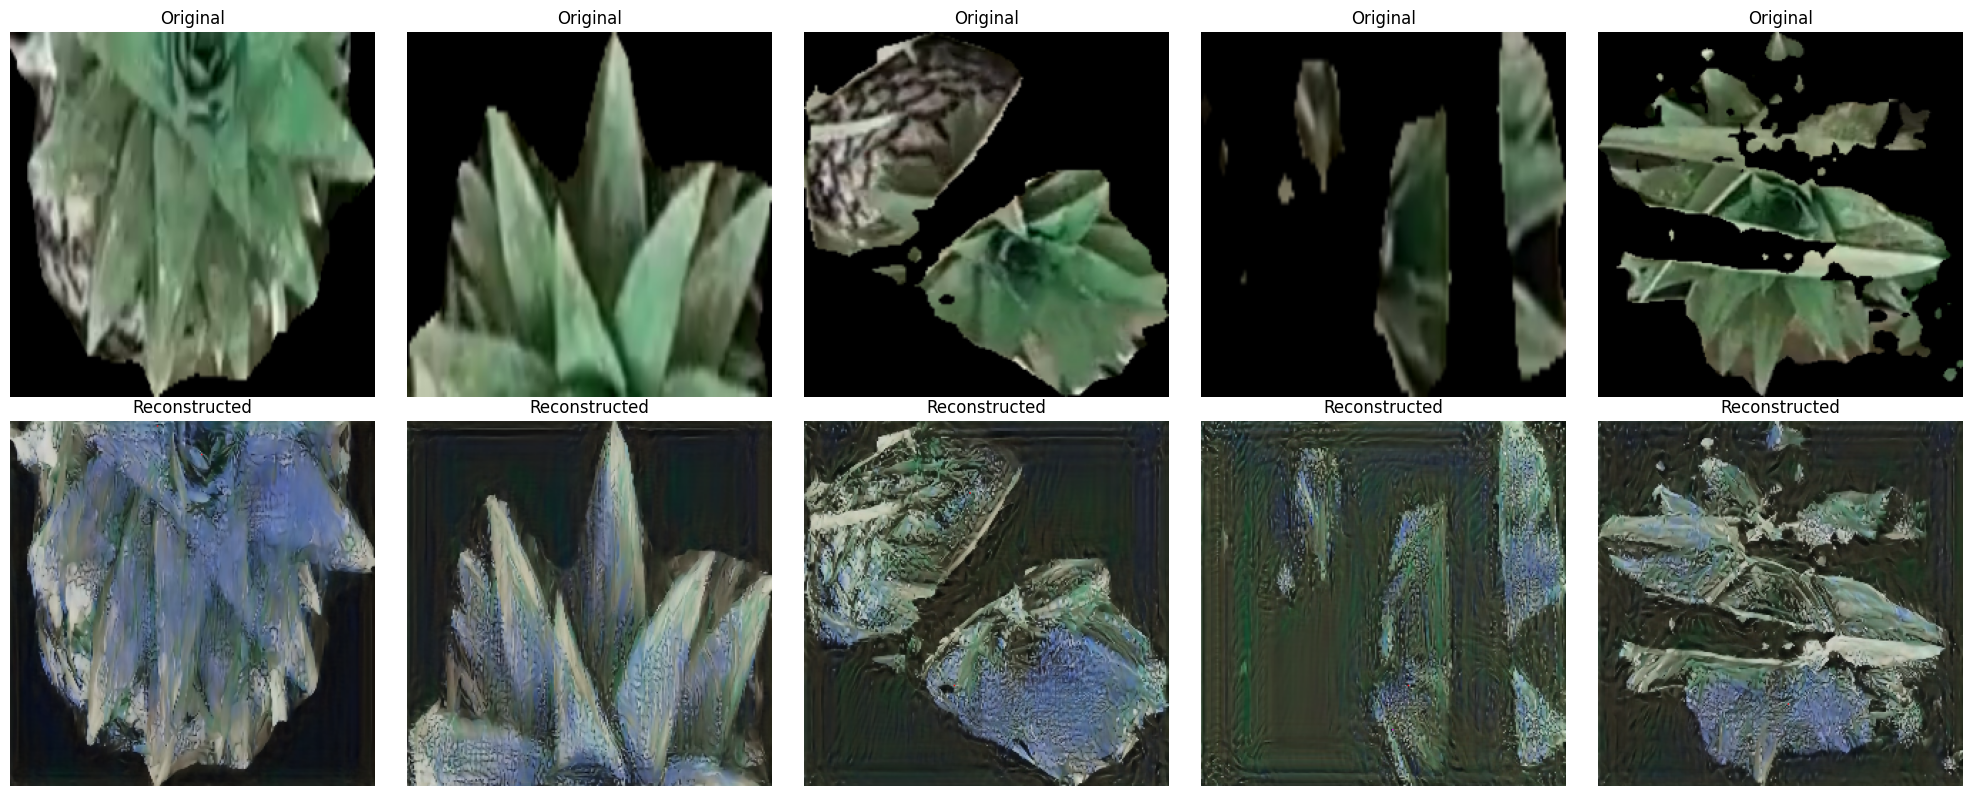

In [7]:
visualize_reconstructions(model, test_set, num_samples=5, img="image")

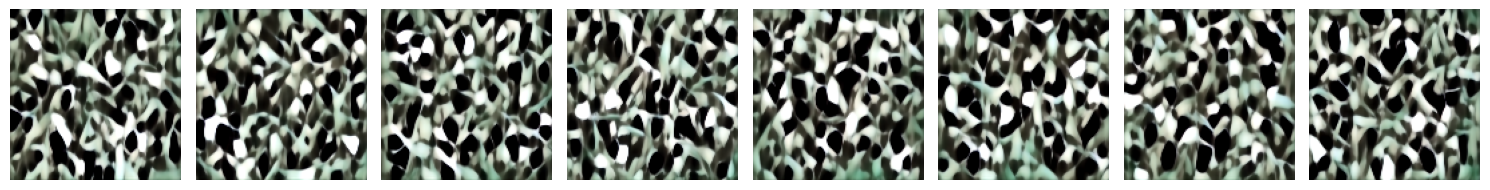

In [8]:
import matplotlib.pyplot as plt
import torch

# Your code
batch_size = 8
height, width = 128, 128
latent = torch.randn(batch_size, 4, height // 8, width // 8).cuda()

decoder = model.decoder
reconstructed_image = decoder(latent)

# Move tensor to CPU and clamp values (for visualization)
reconstructed_image = reconstructed_image.detach().cpu().clamp(0, 1)

# Plot the images
n_images = min(batch_size, 8)  # Plot up to 8 images
fig, axes = plt.subplots(1, n_images, figsize=(15, 3))
for i in range(n_images):
    img = reconstructed_image[i].permute(1, 2, 0)  # CHW -> HWC
    axes[i].imshow(img)
    axes[i].axis("off")
plt.tight_layout()
plt.show()

1176 latent vectors extracted
Cleaned data shape: (1176, 4096)


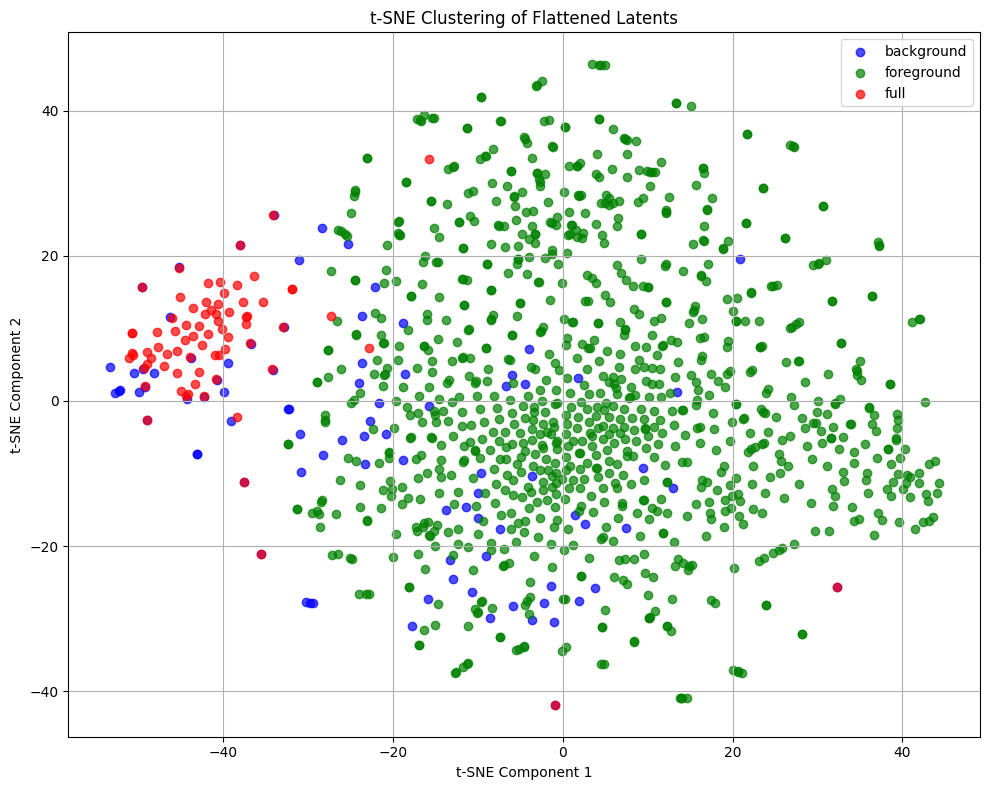

In [9]:
extract_and_visualize_latents(model, test_loader)

In [10]:
model = VAE()
checkpoint_path = "/home/rtxmsi1/Documents/VAE_training-master/checkpoints/vae/betaKL@0.25/weights_ck_199.pt"  # Replace with your checkpoint file
checkpoint = torch.load(checkpoint_path)
model.load_state_dict(checkpoint)

<All keys matched successfully>

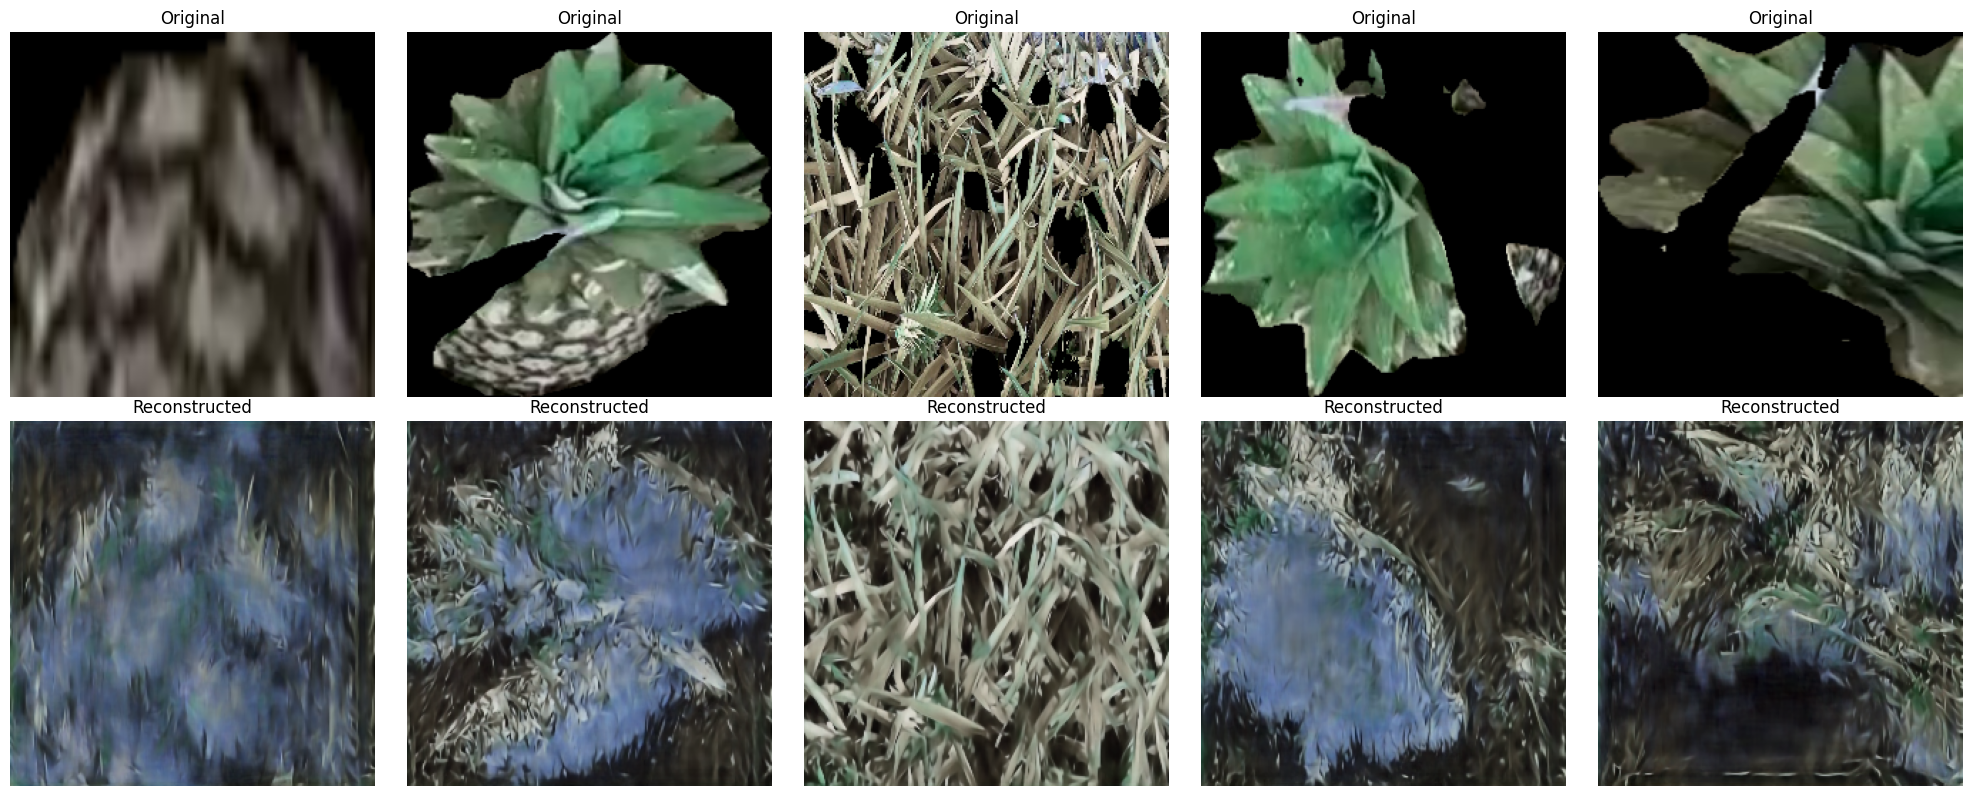

In [11]:
visualize_reconstructions(model, test_set, num_samples=5)

1176 latent vectors extracted
Cleaned data shape: (1176, 4096)


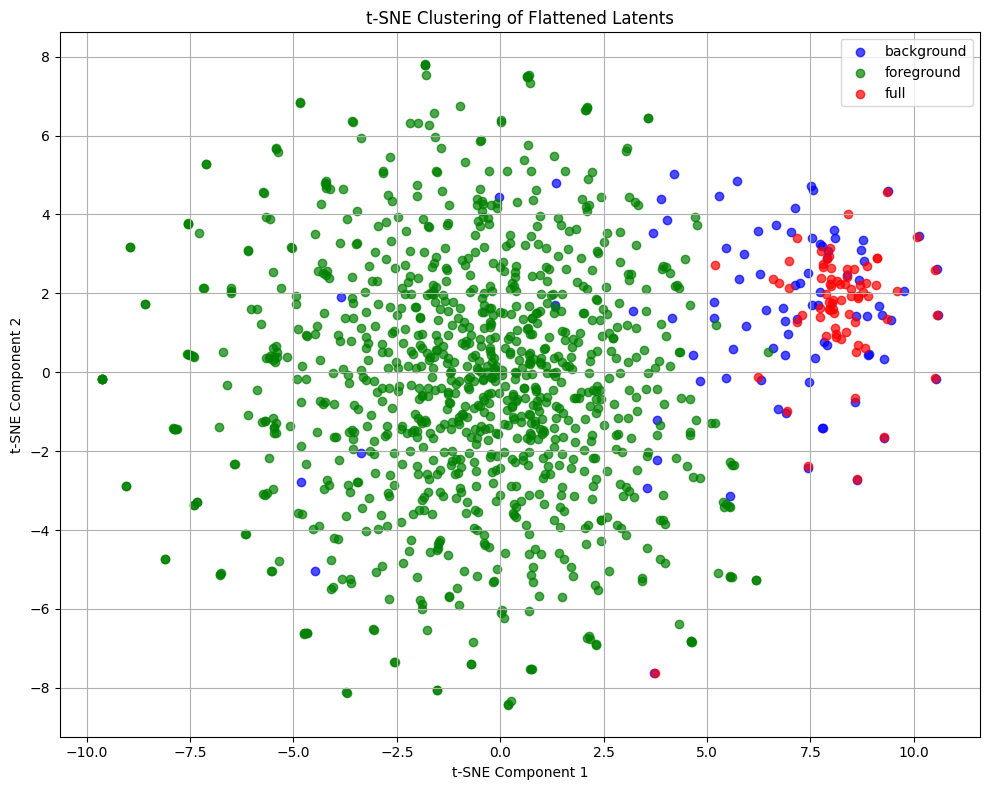

In [12]:
extract_and_visualize_latents(model, test_loader)

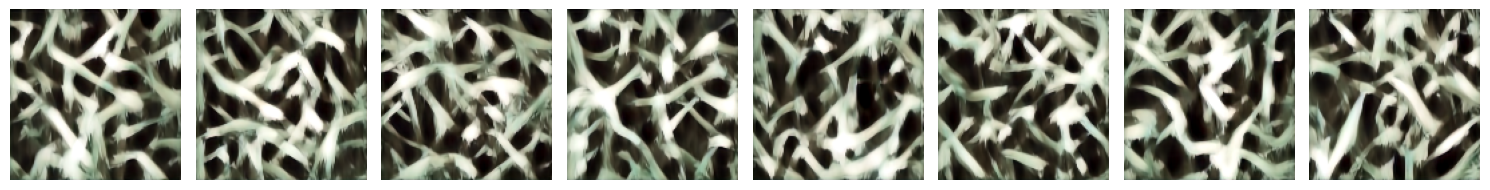

In [23]:
import matplotlib.pyplot as plt
import torch

# Your code
batch_size = 8
height, width = 128, 128
latent = torch.randn(batch_size, 4, height // 8, width // 8).cuda()

decoder = model.decoder
reconstructed_image = decoder(latent)

# Move tensor to CPU and clamp values (for visualization)
reconstructed_image = reconstructed_image.detach().cpu().clamp(0, 1)

# Plot the images
n_images = min(batch_size, 8)  # Plot up to 8 images
fig, axes = plt.subplots(1, n_images, figsize=(15, 3))
for i in range(n_images):
    img = reconstructed_image[i].permute(1, 2, 0)  # CHW -> HWC
    axes[i].imshow(img)
    axes[i].axis("off")
plt.tight_layout()
plt.show()